<img src="https://github.com/djp840/MSDS_453_Public/blob/main/images/NorthwesternHeader.png?raw=1">

## MSDS453 - Research Assignment 03 - Ontology Plus Context and Modeling

Take the ontology that you developed in week 6 and consider how your ten chosen documents for this quarter's class corpus map to that ontology.

Protégé is a tool that takes inputs for a human-created Ontology and creates a visualization.

Use Python algorithms to generate Knowledge Graphs from your documents.

TensorFlow Bidirectional RNN Model

In [1]:
%%bash
# Cell 1 – one-time install (takes a few minutes)

pip install -q numpy==1.26.4 scipy==1.12.0 gensim==4.3.0


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 1.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.4/60.4 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.3/18.3 MB 36.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 38.4/38.4 MB 10.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.1/24.1 MB 13.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.6/59.6 kB 2.2 MB/s eta 0:00:00


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
thinc 8.3.6 requires numpy<3.0.0,>=2.0.0, but you have numpy 1.26.4 which is incompatible.


In [ ]:
# Cell 2 – force Colab to restart the *kernel* itself
import os, signal, sys
os.kill(os.getpid(), signal.SIGTERM)
# Session will "crash" here

In [1]:
# Cell 3: Verify installation and import all libraries
# After the automatic restart, this will be the first cell to run

# In Google Colab, select Runtime > Run cell and below
import numpy as np, gensim
print("NumPy :", np.__version__)     # 1.26.4
print("Gensim:", gensim.__version__) # 4.3.0

NumPy : 1.26.4
Gensim: 4.3.0


In [2]:
import pandas as pd
import numpy as np
import re
import string
import seaborn as sns
import matplotlib.pyplot as plt
import nltk
from collections import Counter
from dataclasses import dataclass
from timeit import default_timer as timer

from nltk.corpus import stopwords
from nltk.stem.wordnet import WordNetLemmatizer
from nltk.tokenize import word_tokenize

import gensim
from gensim.models import Word2Vec

import spacy
from spacy import displacy

from spacy.matcher import Matcher
from spacy.tokens import Span

import networkx as nx
import matplotlib.pyplot as plt
from tqdm import tqdm


from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, f1_score
from sklearn.model_selection import train_test_split

from IPython.display import display, HTML

from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import accuracy_score, f1_score

import tensorflow as tf
from tensorflow import keras
import tensorflow_datasets as tfds
tf.random.set_seed(2022)
import tensorflow.keras.backend as k

from typing import List, Callable, Dict, Tuple, Set

from transformers import pipeline

<div class="alert alert-block alert-danger">
<b>Required Installation: en_core_web_lg</b><br>"python -m spacy download en_core_web_lg"<br><br>English pipeline optimized for CPU. Components: tok2vec, tagger, parser, senter, ner, attribute_ruler, lemmatizer<br>
    <b>https://spacy.io/models/en#en_core_web_lg </b>
</div>

## Requires Restart Of Runtime After Installation

In [3]:
!python -m spacy download en_core_web_lg -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 400.7/400.7 MB 4.5 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_lg')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [4]:
nlp = spacy.load('en_core_web_lg')

### Mount Google Drive to Colab Environment

In [5]:
#from google.colab import drive
#drive.mount('/content/gdrive')

In [6]:
#! ls -l /content/gdrive

### NLTK Downloads

In [7]:
# Only run this once, they will be downloaded.
nltk.download('stopwords',quiet=True)
nltk.download('wordnet',quiet=True)
nltk.download('punkt',quiet=True)
nltk.download('omw-1.4',quiet=True)
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

<div class="alert alert-block alert-danger">
<b>Gensim</b> is a Python library for topic modelling, document indexing and similarity retrieval with large corpora. Target audience is the natural language processing (NLP) and information retrieval (IR) community <br><br>
    <b>https://pypi.org/project/gensim/ </b>
</div>

In [8]:
import pkg_resources
#pkg_resources.require("gensim<=3.8.3");

<ipython-input-8-da50371301cc>:1: DeprecationWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html
  import pkg_resources


In [9]:
print("Genism Version: ", gensim.__version__)

Genism Version:  4.3.0


<div class="alert alert-block alert-info">
    <b>Suppress warning messages</b></div>

In [10]:
def warn(*args, **kwargs):
    pass
import warnings
warnings.warn = warn

## Data Wrangling Utility Functions

In [11]:
def add_movie_descriptor(data: pd.DataFrame, corpus_df: pd.DataFrame):
    """
    Adds "Movie Description" to the supplied dataframe, in the form {Genre}_{P|N}_{Movie Title}_{DocID}
    """
    review = np.where(corpus_df['Review Type (pos or neg)'] == 'Positive', 'P', 'N')
    data['Descriptor'] = corpus_df['Genre of Movie'] + '_' + corpus_df['Movie Title'] + '_' + review + '_' + corpus_df['Doc_ID'].astype(str)

def get_corpus_df(path: str) -> pd.DataFrame:
    data = pd.read_csv(path,encoding="utf-8")
    add_movie_descriptor(data, data)
    sorted_data = data.sort_values(['Descriptor'])
    indexed_data = sorted_data.set_index(['Doc_ID'])
    indexed_data['Doc_ID'] = indexed_data.index
    return indexed_data

def remove_punctuation(text: str) -> str:
    return re.sub('[^a-zA-Z]', '', str(text))

def remove_tags(text: str) -> str:
    return re.sub('&lt;/?.*?&gt;', '', text)

def remove_special_chars_and_digits(text: str) -> str:
    return re.sub('(\\d|\\W)+', '', text)

def get_sentences(text: str) -> List[str]:
    return [str(x) for x in nlp(text).sents]

def get_coref_resolved_sentences(text: str) -> List[str]:
    return [str(x) for x in nlp(text).sents]

def get_lemmas(text: str, stopwords: Set[str]) -> List[str]:
    initial = [remove_tags(remove_special_chars_and_digits(remove_punctuation(x.lemma_.lower()))) for x in nlp(text)]
    return [x for x in initial if x not in stopwords]

def lemmatize_sentence(text: str, stopwords: Set[str]) -> str:
    return ' '.join(get_lemmas(text, stopwords))

def clean_doc(doc):
    #doc = remove_punctuation(doc)
    doc= ' '.join(remove_stop_words(doc))
    doc = apply_lemmatization(doc)
    return doc

def remove_stop_words(in_text):
    stop_words = set(stopwords.words('english'))
    word_tokens = word_tokenize(in_text)
    filtered_sentence = [w for w in word_tokens if not w in stop_words]
    return filtered_sentence

def apply_lemmatization(in_text):
    # Lemmatization
    lem = WordNetLemmatizer()
    word_list = nltk.word_tokenize(in_text)
    output = ' '.join([lem.lemmatize(w) for w in word_list])
    return output

def counter_word(text):
  count=Counter()
  for i in text.values:
    for word in i.split():
      count[word]=+1
  return count

## Knowledge Context Graph Functions

In [12]:
def map_edges(map_to: str, map_from: Set[str], df: pd.DataFrame):
    print(f'Before mapping {", ".join(map_from)} -> {map_to}: {sum(df.edge == map_to)}')
    df['edge'] = np.where(kg_df.edge.isin(map_from), map_to, kg_df.edge)
    print(f'After mapping {", ".join(map_from)} -> {map_to}: {sum(df.edge == map_to)}')

def map_sources_and_targets(map_to: str, map_from: Set[str], df: pd.DataFrame):
    before = sum(df.source == map_to) + sum(df.target == map_to)
    print(f'Before mapping {", ".join(map_from)} -> {map_to}: {before}')

    df['source'] = np.where(kg_df.source.isin(map_from), map_to, kg_df.source)
    df['target'] = np.where(kg_df.target.isin(map_from), map_to, kg_df.target)

    after = sum(df.source == map_to) + sum(df.target == map_to)
    print(f'After mapping {", ".join(map_from)} -> {map_to}: {after}')

def get_neighborhood(sources: Set[str], edge_types: Set[str], depth: int, df: pd.DataFrame) -> pd.DataFrame:
    output = []

    for d in range(depth):
        if edge_types is not None:
            rows = df[(df.edge.isin(edge_types)) & ((df.source.isin(sources)) | (df.target.isin(sources)))].copy()
        else:
            rows = df[(df.source.isin(sources)) | (df.target.isin(sources))].copy()

        output.append(rows)
        sources = set(rows.target).union(set(rows.source))

    return pd.concat(output).drop_duplicates()

def find_sources_and_targets_with_patterns(patterns: List[str], df: pd.DataFrame):
    mask = np.zeros(kg_df.shape[0])
    for pattern in patterns:
        mask = mask | (df.source.str.contains(pattern)) | (df.target.str.contains(pattern))

    return df[mask]
# Examples of how to use the function:
# find_sources_and_targets_with_patterns(['action'], kg_df)
# find_sources_and_targets_with_patterns(['terror'], kg_df)
# find_sources_and_targets_with_patterns(['novel'], kg_df)
# find_sources_and_targets_with_patterns(['director', 'campbell'], kg_df)


def plot_graph(df: pd.DataFrame, show_edges: bool = False, figsize: Tuple[int, int] = (12, 12), use_circular: bool=True):
    graph = nx.from_pandas_edgelist(df, "source", "target", edge_attr='edge', create_using=nx.MultiDiGraph())

    plt.figure(figsize=figsize)
    if use_circular:
        pos = nx.circular_layout(graph)
    else:
        pos = nx.kamada_kawai_layout(graph)

    nx.draw(graph, with_labels=True, node_color='skyblue', edge_cmap=plt.cm.Blues, pos=pos)
    if show_edges:
        nx.draw_networkx_edge_labels(graph, pos=pos, font_size=8)

    plt.show()

def get_top_sources_and_targets(df: pd.DataFrame, top: int = 10):
    return (Counter(df.source) + Counter(df.target)).most_common(top)

def get_top_edges(df: pd.DataFrame, top: int = 10):
    return Counter(df.edge).most_common(top)

def get_dataset_partitions_pd(df, train_split=0.8, val_split=0.10, test_split=0.10):
       # Specify seed to always have the same split distribution between runs
    df_sample = df.sample(frac=1, random_state=12)
    indices_or_sections = [int(.8*len(df)), int(.9*len(df))]
    train_ds, val_ds, test_ds = np.split(df_sample, indices_or_sections)
    return train_ds, val_ds, test_ds

## Entity Extraction Functions

In [13]:
def get_entities(sent):
  ## chunk 1
  ent1 = ""
  ent2 = ""

  prv_tok_dep = ""    # dependency tag of previous token in the sentence
  prv_tok_text = ""   # previous token in the sentence

  prefix = ""
  modifier = ""

  for tok in nlp(sent):
    ## chunk 2
    # if token is a punctuation mark then move on to the next token
    if tok.dep_ != "punct":
      # check: token is a compound word or not
      if tok.dep_ == "compound":
        prefix = tok.text
        # if the previous word was also a 'compound' then add the current word to it
        if prv_tok_dep == "compound":
          prefix = prv_tok_text + " "+ tok.text

      # check: token is a modifier or not
      if tok.dep_.endswith("mod") == True:
        modifier = tok.text
        # if the previous word was also a 'compound' then add the current word to it
        if prv_tok_dep == "compound":
          modifier = prv_tok_text + " "+ tok.text

      ## chunk 3
      if tok.dep_.find("subj") == True:
        ent1 = modifier +" "+ prefix + " "+ tok.text
        prefix = ""
        modifier = ""
        prv_tok_dep = ""
        prv_tok_text = ""

      ## chunk 4
      if tok.dep_.find("obj") == True:
        ent2 = modifier +" "+ prefix +" "+ tok.text

      ## chunk 5
      # update variables
      prv_tok_dep = tok.dep_
      prv_tok_text = tok.text

  return [ent1.strip(), ent2.strip()]

def get_relation(sent):
    try:
        doc = nlp(sent)

        # Matcher class object
        matcher = Matcher(nlp.vocab)

        #define the pattern
        pattern = [{'DEP':'ROOT'},
                {'DEP':'prep','OP':"?"},
                {'DEP':'agent','OP':"?"},
                {'POS':'ADJ','OP':"?"}]
        matcher.add("matching_1", [pattern])
        matches = matcher(doc)
        k = len(matches) - 1
        span = doc[matches[k][1]:matches[k][2]]

        return(span.text)
    except:
        pass

def get_subject_verb_object(sent):
  ent1 = ""
  ent2 = ""
  root = ""

  for tok in nlp(sent):
      if tok.dep_ == 'ROOT':
        root = tok.text
      elif tok.dep_ == "nsubj":
        ent1 = tok.text
      elif tok.dep_ == "dobj":
        ent2 = tok.text

      if ent1 != '' and ent2 != '' and root != '':
        break

  return [ent1, root, ent2]

## Visualization Utility Functions

In [14]:
def plot_confusion_matrix_labeled(y_true, y_pred, CLASSES_LIST):
    mtx = confusion_matrix(y_true, y_pred)
    # define classes
    classes = CLASSES_LIST
    temp_df = pd.DataFrame(data=mtx,columns=classes)
    temp_df.index = classes
    fig, ax = plt.subplots(figsize=(10,10))
    sns.heatmap(temp_df, annot=True, fmt='d', linewidths=.75,  cbar=False, ax=ax,cmap='Blues',linecolor='white')
    #  square=True,
    plt.ylabel('true label')
    plt.xlabel('predicted label')

def plot_graphs(history, metric):
  plt.plot(history.history[metric])
  plt.plot(history.history['val_'+metric], '')
  plt.xlabel("Epochs")
  plt.ylabel(metric)
  plt.legend([metric, 'val_'+metric])

def display_training_curves(training, validation, title, subplot):
  ax = plt.subplot(subplot)
  ax.plot(training)
  ax.plot(validation)
  ax.set_title('model '+ title)
  ax.set_ylabel(title)
  ax.set_xlabel('epoch')
  ax.legend(['training', 'validation'])

## Loading the Class Corpus

In [15]:
CORPUS_PATH=\
'https://raw.githubusercontent.com/barrycforever/MSDS_453_NLP/main/MSDS453_ClassCorpus/MSDS453_QA_20220906.csv'

corpus_df = get_corpus_df(CORPUS_PATH)

## Exploratory Data Analysis

In [16]:
# Tokenize sentences
corpus_df['raw_sentences'] = corpus_df.Text.apply(get_sentences)
corpus_df.head(3).T

Doc_ID,40,41,42
DSI_Title,KCM_Doc1_AngelHasFallen,KCM_Doc2_AngelHasFallen,KCM_Doc3_AngelHasFallen
Text,Boredom sets in long before the start of Angel...,\nWho ARE all these people?\n\nThat was what...,Ric Roman Waughs Angel Has Fallen sees U.S. S...
Submission File Name,KCM_Doc1_AngelHasFallen,KCM_Doc2_AngelHasFallen,KCM_Doc3_AngelHasFallen
Student Name,KCM,KCM,KCM
Genre of Movie,Action,Action,Action
Review Type (pos or neg),Negative,Negative,Negative
Movie Title,Angel Has Fallen,Angel Has Fallen,Angel Has Fallen
Descriptor,Action_Angel Has Fallen_N_40,Action_Angel Has Fallen_N_41,Action_Angel Has Fallen_N_42
Doc_ID,40,41,42
raw_sentences,[Boredom sets in long before the start of Ange...,[\nWho ARE all these people?\n\nThat was wha...,[Ric Roman Waughs Angel Has Fallen sees U.S. ...


## Tokenize Words

In [17]:
default_stopwords=\
set(nltk.corpus.stopwords.words('english')).union(set(nlp.Defaults.stop_words)).union({' ', ''})
corpus_df['lemmas'] = corpus_df.Text.apply(lambda x: get_lemmas(x, default_stopwords))
corpus_df.lemmas.head()

,lemmas
Doc_ID,
40,"[boredom, set, long, start, angel, fall, start..."
41,"[people, mutter, enter, screening, angel, fall..."
42,"[ric, roman, waughs, angel, fallen, secret, se..."
43,"[certain, mindless, pleasure, fallen, movie, w..."
44,"[dont, need, olympus, fallen, andor, london, f..."


In [18]:
corpus_df.head(3).T

Doc_ID,40,41,42
DSI_Title,KCM_Doc1_AngelHasFallen,KCM_Doc2_AngelHasFallen,KCM_Doc3_AngelHasFallen
Text,Boredom sets in long before the start of Angel...,\nWho ARE all these people?\n\nThat was what...,Ric Roman Waughs Angel Has Fallen sees U.S. S...
Submission File Name,KCM_Doc1_AngelHasFallen,KCM_Doc2_AngelHasFallen,KCM_Doc3_AngelHasFallen
Student Name,KCM,KCM,KCM
Genre of Movie,Action,Action,Action
Review Type (pos or neg),Negative,Negative,Negative
Movie Title,Angel Has Fallen,Angel Has Fallen,Angel Has Fallen
Descriptor,Action_Angel Has Fallen_N_40,Action_Angel Has Fallen_N_41,Action_Angel Has Fallen_N_42
Doc_ID,40,41,42
raw_sentences,[Boredom sets in long before the start of Ange...,[\nWho ARE all these people?\n\nThat was wha...,[Ric Roman Waughs Angel Has Fallen sees U.S. ...


## Reassemble Leminized Words

In [19]:
corpus_df['lemmas_joined'] = corpus_df.lemmas.apply(lambda x: ' '.join(x))

In [20]:
corpus_df['lemmas_joined'].head()

,lemmas_joined
Doc_ID,
40,boredom set long start angel fall start journe...
41,people mutter enter screening angel fallen loc...
42,ric roman waughs angel fallen secret service a...
43,certain mindless pleasure fallen movie watch g...
44,dont need olympus fallen andor london fallen u...


In [21]:
corpus_df.head(3).T

Doc_ID,40,41,42
DSI_Title,KCM_Doc1_AngelHasFallen,KCM_Doc2_AngelHasFallen,KCM_Doc3_AngelHasFallen
Text,Boredom sets in long before the start of Angel...,\nWho ARE all these people?\n\nThat was what...,Ric Roman Waughs Angel Has Fallen sees U.S. S...
Submission File Name,KCM_Doc1_AngelHasFallen,KCM_Doc2_AngelHasFallen,KCM_Doc3_AngelHasFallen
Student Name,KCM,KCM,KCM
Genre of Movie,Action,Action,Action
Review Type (pos or neg),Negative,Negative,Negative
Movie Title,Angel Has Fallen,Angel Has Fallen,Angel Has Fallen
Descriptor,Action_Angel Has Fallen_N_40,Action_Angel Has Fallen_N_41,Action_Angel Has Fallen_N_42
Doc_ID,40,41,42
raw_sentences,[Boredom sets in long before the start of Ange...,[\nWho ARE all these people?\n\nThat was wha...,[Ric Roman Waughs Angel Has Fallen sees U.S. ...


## Vocabulary Data Wrangling

In [22]:
vectorizer = CountVectorizer(ngram_range=(1, 1))
transformed_documents = vectorizer.fit_transform(corpus_df.lemmas_joined)
doc_term_matrix = transformed_documents.todense()
doc_term_df = pd.DataFrame(doc_term_matrix,
                           columns=vectorizer.get_feature_names_out(),
                           index=corpus_df.Descriptor)
print(f'All Word Vocabulary size: {doc_term_df.shape[1]}')
all_words = set(doc_term_df.columns)

vectorizer = CountVectorizer(ngram_range=(1, 1), min_df=5, max_df=.8)
transformed_documents = vectorizer.fit_transform(corpus_df.lemmas_joined)
doc_term_matrix = transformed_documents.todense()
doc_term_df = pd.DataFrame(doc_term_matrix,
                           columns=vectorizer.get_feature_names_out(),
                           index=corpus_df.Descriptor)
print(f'Curated Vocabulary size: {doc_term_df.shape[1]}')
vocabulary = set(doc_term_df.columns)

words_to_remove = default_stopwords.union(all_words - vocabulary)

All Word Vocabulary size: 12165
Curated Vocabulary size: 2907


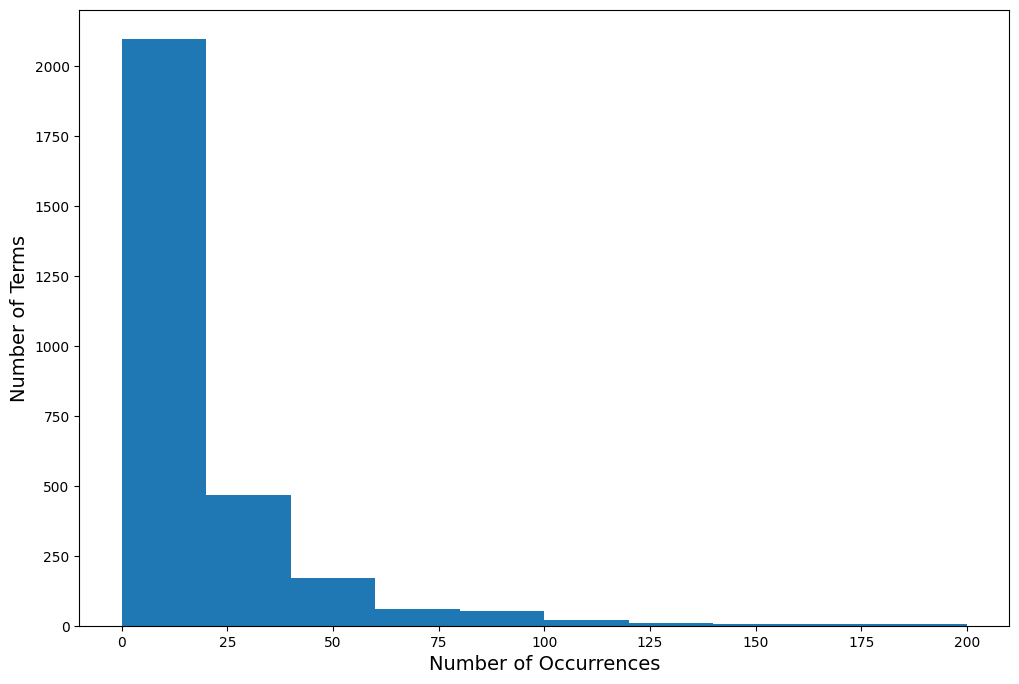

In [23]:
plt.figure(figsize = (12, 8))
plt.hist(doc_term_df.sum(axis=0).T, range=(0, 200))
plt.xlabel('Number of Occurrences',fontsize=14)
plt.ylabel('Number of Terms',fontsize=14);

In [24]:
# Re-tokenize words, recreate joined documents
corpus_df['lemmas'] = corpus_df.Text.apply(lambda x: get_lemmas(x, words_to_remove))
corpus_df['lemmas_joined'] = corpus_df.lemmas.apply(lambda x: ' '.join(x))
corpus_df.lemmas.head()

,lemmas
Doc_ID,
40,"[set, long, start, angel, fall, start, journey..."
41,"[people, enter, angel, fallen, local, cinema, ..."
42,"[ric, roman, angel, fallen, secret, service, a..."
43,"[certain, pleasure, fallen, watch, gerard, but..."
44,"[dont, need, olympus, fallen, andor, london, f..."


## Get Lemmatized and Filtered Sentences

Removes the additional words

In [25]:
corpus_df['sentences_lemmatized']=\
corpus_df.raw_sentences.apply(lambda x: [lemmatize_sentence(s, words_to_remove) for s in x])

In [26]:
corpus_df.head().T

Doc_ID,40,41,42,43,44
DSI_Title,KCM_Doc1_AngelHasFallen,KCM_Doc2_AngelHasFallen,KCM_Doc3_AngelHasFallen,KCM_Doc4_AngelHasFallen,KCM_Doc5_AngelHasFallen
Text,Boredom sets in long before the start of Angel...,\nWho ARE all these people?\n\nThat was what...,Ric Roman Waughs Angel Has Fallen sees U.S. S...,There is a certain mindless pleasure in the Fa...,"No, you dont need to have seen Olympus Has F..."
Submission File Name,KCM_Doc1_AngelHasFallen,KCM_Doc2_AngelHasFallen,KCM_Doc3_AngelHasFallen,KCM_Doc4_AngelHasFallen,KCM_Doc5_AngelHasFallen
Student Name,KCM,KCM,KCM,KCM,KCM
Genre of Movie,Action,Action,Action,Action,Action
Review Type (pos or neg),Negative,Negative,Negative,Negative,Negative
Movie Title,Angel Has Fallen,Angel Has Fallen,Angel Has Fallen,Angel Has Fallen,Angel Has Fallen
Descriptor,Action_Angel Has Fallen_N_40,Action_Angel Has Fallen_N_41,Action_Angel Has Fallen_N_42,Action_Angel Has Fallen_N_43,Action_Angel Has Fallen_N_44
Doc_ID,40,41,42,43,44
raw_sentences,[Boredom sets in long before the start of Ange...,[\nWho ARE all these people?\n\nThat was wha...,[Ric Roman Waughs Angel Has Fallen sees U.S. ...,[There is a certain mindless pleasure in the F...,"[No, you dont need to have seen Olympus Has ..."


## Review Documents By Movie Title

In [27]:
print(corpus_df['Movie Title'].unique())

['Angel Has Fallen' 'Inception' 'No Time To Die' 'Taken' 'Taxi'
 'Despicable Me 3' 'Dirty Grandpa' 'Holmes and Watson' 'Legally Blonde'
 'The Lost City' 'Drag me to hell' 'Fresh' 'It Chapter Two'
 'The Toxic Avenger' 'US' 'Batman' 'Equilibrium' 'Minority Report'
 'Oblivion' 'Pitch Black']


In [28]:
movie_df = corpus_df[corpus_df['Movie Title'] == 'Dirty Grandpa'].copy()
# or
#movie_df = corpus_df[corpus_df['Movie Title'] == 'Dirty_Grandpa'].copy()
movie_df.head(3).T

Doc_ID,35,36,37
DSI_Title,PYC_Doc6_DirtyGrandpa,PYC_Doc7_DirtyGrandpa,PYC_Doc8_DirtyGrandpa
Text,"Make no mistake about it, Robert De Niro is a ...",This is a very disturbing and difficult movie ...,"On Jan. 22, “Dirty Grandpa” was unleashed on t..."
Submission File Name,PYC_Doc6_DirtyGrandpa,PYC_Doc7_DirtyGrandpa,PYC_Doc8_DirtyGrandpa
Student Name,PYC,PYC,PYC
Genre of Movie,Comedy,Comedy,Comedy
Review Type (pos or neg),Negative,Negative,Negative
Movie Title,Dirty Grandpa,Dirty Grandpa,Dirty Grandpa
Descriptor,Comedy_Dirty Grandpa_N_35,Comedy_Dirty Grandpa_N_36,Comedy_Dirty Grandpa_N_37
Doc_ID,35,36,37
raw_sentences,"[Make no mistake about it, Robert De Niro is a...",[This is a very disturbing and difficult movie...,"[On Jan. 22, “Dirty Grandpa” was unleashed on ..."


## Knowledge Graph Extraction

In [29]:
corpus_text_sentences = [y for x in movie_df.raw_sentences for y in x]
example_sentence = nlp(corpus_text_sentences[5])
corpus_text_sentences[5]

'The film’s plot (what there is of it) centers on\xa0an uptight young lawyer, Jason (Efron), who is about to be married to a wedding-obsessed fiancee (a one-note Julianne Hough).'

In [30]:
entity_pairs = [get_entities(x) for x in tqdm(corpus_text_sentences)]

100%|██████████| 300/300 [00:02<00:00, 109.85it/s]


In [31]:
entity_pairs

[['Robert De Niro', 'it'],
 ['worst movie anyone', 'also  mistake'],
 ['especially distributor Lionsgate', 'first  place'],
 ['where opening I', 'it'],
 ['word', 'steaming  pile'],
 ['young  who', 'obsessed  fiancee'],
 ['lecherous De wife', '40  years'],
 ['he', 'clad college age girls'],
 ['Jason', 'him'],
 ['out  film', 'high  comparison'],
 ['Years  Slave', 'this'],
 ['that', 'called  humor'],
 ['naked  Efron', 'mistaken child molestation'],
 ['', ''],
 ['three  what', 'year'],
 ['laughs', 'it'],
 ['immediately IMDb that', 'immediately IMDb laughs'],
 ['how Dermot roles', 'Danny Glover'],
 ['where  forehead', 'male Nazi members'],
 ['I', 'stuff'],
 ['This', ''],
 ['what', 'them'],
 ['stuffed smoking it', 'stuffed smoking bee'],
 ['us', 'river'],
 ['river', 'glory'],
 ['that', ''],
 ['depicted', ''],
 ['only De sparks', 'Aubrey Plaza'],
 ['time  she', 'frame'],
 ['scene she', 'better De movie'],
 ['Apart  movie', 'lawless dirtbag playground'],
 ['inexplicable Dick plot', 'turns'],
 

### Create DataFrame (Source, Target, Edge)

In [32]:
relations = [get_relation(x) for x in corpus_text_sentences]
#extract subject and object
source = [i[0] for i in entity_pairs]
target = [i[1] for i in entity_pairs]
kg_df = pd.DataFrame({'source': source, 'target': target, 'edge': relations})

### Knowledge Graph Preprocessing (Lowercase, Remove Empty Spaces)

In [33]:
# Move everything to lower case
kg_df.source = kg_df.source.str.lower()
kg_df.target = kg_df.target.str.lower()
kg_df.edge = kg_df.edge.str.lower()

# Filter out empties
kg_df = kg_df[kg_df.source != '']
kg_df = kg_df[kg_df.target != '']
kg_df = kg_df[kg_df.edge != ''].copy()

In [34]:
kg_df.head(6).T

,0,1,2,3,4,5
source,robert de niro,worst movie anyone,especially distributor lionsgate,where opening i,word,young who
target,it,also mistake,first place,it,steaming pile,obsessed fiancee
edge,is,make,is,seem,be disastrous,centers on


In [35]:
kg_df.shape

(248, 3)

In [36]:
len(corpus_text_sentences)

300

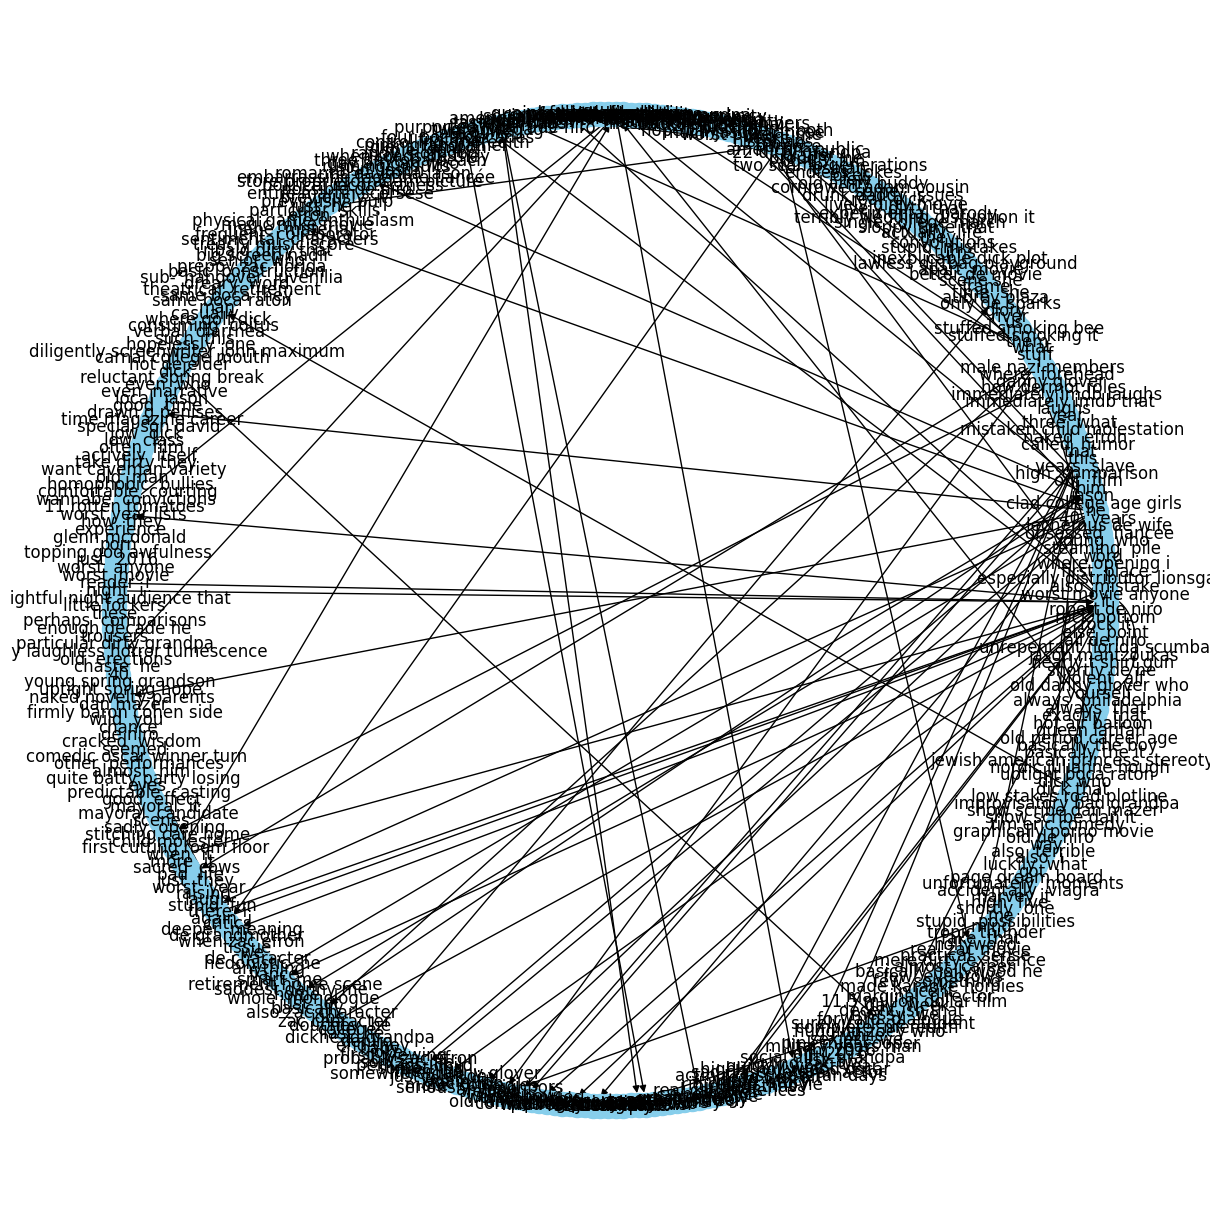

In [37]:
plot_graph(kg_df, use_circular=True)

BERT NER (Named Entity Recognition)

In [38]:
# NER Setup with BERT
def setup_ner_pipeline(model_name="dbmdz/bert-large-cased-finetuned-conll03-english"):
    """
    Set up the NER pipeline using the specified BERT model.
    """
    try:
        ner_pipeline = pipeline("ner", model=model_name, aggregation_strategy="simple")
        print("NER pipeline set up successfully.")
        return ner_pipeline
    except Exception as e:
        print(f"An error occurred while setting up the NER pipeline: {e}")
        return None

In [39]:
# Performing NER and Storing Results in DataFrames
def perform_ner_and_store_in_df(data, ner_pipeline):
    """
    Perform NER on the loaded dataset using the specified NER pipeline and store the results in DataFrames.
    The dataset should have 'title' and 'content' columns.
    """
    if data is not None and ner_pipeline is not None:
        titles = data['title']
        contents = data['content']
        df_dict = {}
        for title, text in zip(titles, contents):
            print ("Processing: ", title)
            entities = ner_pipeline(text)
            df_dict[title] = pd.DataFrame(entities)
        print("NER processing completed.")
        return df_dict
    else:
        print("Data or NER pipeline is not properly initialized.")
        return {}

In [40]:
# Set up the NER pipeline
ner_pipeline = setup_ner_pipeline()

# Make a new dataframe "data" for use with NER; copying and renaming columns
data_raw = corpus_df.rename(columns={'Movie Title': 'title', 'raw_sentences': 'content'}).copy()

config.json:   0%|          | 0.00/998 [00:00<?, ?B/s]

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


model.safetensors:   0%|          | 0.00/1.33G [00:00<?, ?B/s]

Some weights of the model checkpoint at dbmdz/bert-large-cased-finetuned-conll03-english were not used when initializing BertForTokenClassification: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight']
- This IS expected if you are initializing BertForTokenClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertForTokenClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


tokenizer_config.json:   0%|          | 0.00/60.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/213k [00:00<?, ?B/s]

Device set to use cpu


NER pipeline set up successfully.


In [41]:
# TEST ON MOVIE REVIEWS FOR ONE MOVIE

# Sample title for testing

specific_title = 'Dirty Grandpa'  # Adjust this title based on your actual data
#specific_title = 'Batman'  # Adjust this title based on your actual data


# Example filtering for just one movie, can be extended with logical operators
data = data_raw.query("title == '"+ specific_title +"'").copy()
# For multiple titles, you can use or "|"
#data = data_raw.query("title == 'Movie Title 1' | title == 'Movie Title 2'").copy()

In [42]:
# OR IF YOU WANT TO DO NER FOR ALL MOVIE REVIEWS, uncomment this line:
#data= data_raw

In [43]:
# Perform NER on the dataset and store results in DataFrame
# This can take some time.
df_dict = perform_ner_and_store_in_df(data, ner_pipeline)

Processing:  Dirty Grandpa
Processing:  Dirty Grandpa
Processing:  Dirty Grandpa
Processing:  Dirty Grandpa
Processing:  Dirty Grandpa
Processing:  Dirty Grandpa
Processing:  Dirty Grandpa
Processing:  Dirty Grandpa
Processing:  Dirty Grandpa
Processing:  Dirty Grandpa
NER processing completed.


In [44]:
# Print all document titles in the NER resutls
df_dict.keys()

dict_keys(['Dirty Grandpa'])

In [46]:
# How the returned extracted data is represented...

# Raw form:
#df_dict
#print("========")

row_at_index_0 = df_dict['Dirty Grandpa'].iloc[0]
#row_at_index_0 = df_dict['Batman'].iloc[0]
print(row_at_index_0)
print("========")

# print(df_dict['Batman'].iloc[0,0])
# print(df_dict['Batman'].iloc[1,0])
# print(df_dict['Batman'].iloc[2,0])

print(df_dict['Dirty Grandpa'].iloc[0,0])
print(df_dict['Dirty Grandpa'].iloc[1,0])
print(df_dict['Dirty Grandpa'].iloc[2,0])

0    {'entity_group': 'MISC', 'score': 0.855487, 'w...
1                                                 None
2                                                 None
3                                                 None
4                                                 None
5                                                 None
Name: 0, dtype: object
{'entity_group': 'MISC', 'score': 0.855487, 'word': 'Dirty Grandpa', 'start': 24, 'end': 37}
{'entity_group': 'PER', 'score': 0.9930784, 'word': 'Robert De Niro', 'start': 17, 'end': 31}
{'entity_group': 'LOC', 'score': 0.9995003, 'word': 'Hollywood', 'start': 89, 'end': 98}


In [47]:
# Access and print the NER results DataFrame for a specific title

# Check if the specific title exists in the dictionary
if specific_title in df_dict:
    # Access the DataFrame for the specific title
    df_iter = df_dict[specific_title]

    # Initialize an empty list to collect all words (entities)
    all_entities = []

    # Iterate through each row of the DataFrame
    for index, row in df_iter.iterrows():
        # Iterate through each cell in the row
        for cell in row:
            # Check if the cell contains a dictionary and has the expected keys
            if isinstance(cell, dict) and {'entity_group', 'score', 'word', 'start', 'end'}.issubset(cell):
                # Extract entity information from the dictionary
                entity_group = cell['entity_group']
                score = cell['score']
                word = cell['word']
                start = cell['start']
                end = cell['end']

                # Collect the entity details
                all_entities.append({
                    "Entity": word,
                    "Type": entity_group,
                    "Score": score,
                    "Start": start,
                    "End": end
                })

                # Example: Print out the entity information
                print(f"Entity: {word}, Type: {entity_group}, Score: {score}, Start: {start}, End: {end}")

    # If you want to do something with all_entities later, it's available
else:
    print("Title not found in the results.")


Entity: Dirty Grandpa, Type: MISC, Score: 0.8554869890213013, Start: 24, End: 37
Entity: Robert De Niro, Type: PER, Score: 0.9930784106254578, Start: 17, End: 31
Entity: Zac Efron, Type: PER, Score: 0.9653612971305847, Start: 36, End: 45
Entity: Hollywood, Type: LOC, Score: 0.9995002746582031, Start: 89, End: 98
Entity: Dirty Grandpa ”, Type: MISC, Score: 0.8048437237739563, Start: 31, End: 45
Entity: Tropic Thunder, Type: MISC, Score: 0.9395756721496582, Start: 115, End: 129
Entity: Viagra, Type: MISC, Score: 0.9488734006881714, Start: 9, End: 15
Entity: De Niro, Type: PER, Score: 0.9714729189872742, Start: 19, End: 26
Entity: Viagra, Type: MISC, Score: 0.9577281475067139, Start: 37, End: 43
Entity: De Niro, Type: PER, Score: 0.9571895599365234, Start: 67, End: 74
Entity: Harvey Keitel, Type: PER, Score: 0.9928039908409119, Start: 164, End: 177
Entity: Viagra, Type: MISC, Score: 0.7837092280387878, Start: 224, End: 230
Entity: Pinterest, Type: MISC, Score: 0.7460688948631287, Start: 6

In [48]:
# TRANSFER WORDS FROM NER DATA-STRUCTURE TO A SIMPLE LIST

# Initialize an empty list to collect all the "word" values
all_entities = []

# Iterate through each row in the DataFrame
for index, row in df_dict['Dirty Grandpa'].iterrows():
    # Iterate through each column/cell in the row
    for col in row.index:
        # Access the cell value, which is expected to be a dictionary
        cell_value = row[col]
        # Check if the cell value is a dictionary and has the key 'word'
        if isinstance(cell_value, dict) and 'word' in cell_value:
            # Add the "word" value from the dictionary to the list
            all_entities.append(cell_value['word'])

# Now, all_words contains all the "word" values extracted from the dictionaries
print(all_entities)

['Dirty Grandpa', 'Robert De Niro', 'Zac Efron', 'Hollywood', 'Dirty Grandpa ”', 'Tropic Thunder', 'Viagra', 'De Niro', 'Viagra', 'De Niro', 'Harvey Keitel', 'Viagra', 'Pinterest', '“ Dirty Grandpa ”', 'Grandpa', 'De Niro', 'Tim & Eric', 'Dirty Grandpa', 'Da Ali G Show', 'Dan Mazer', '“ Dirty Grandpa ”', '“ Bad Grandpa ”', 'De Niro', 'Dick Kelly', 'Christ', 'Efron', 'Boca Raton', 'De Niro', 'Nordic', 'Julianne Hough', 'Jewish American Princess', 'Dermot Mulroney', 'De Niro', 'Ice Cube', 'It Was a Good Day ”', 'Cocky McBlockerson', 'Efron', '“ The Boy', 'De Niro', 'De Niro', 'Jimmy C', '##ag', '##ney', 'Queen Latifah', 'Dirty Grandpa', 'Mean Streets', 'The Adventures of Rocky and Bullwinkle ”', 'Danny DeVito', 'It', 's Always Sunny in Philadelphia', 'Dirty Grandpa', 'Danny Glover', '“ Alf', 'Aubrey Plaza', 'De Niro', 'Shi', 'Jason Mantzoukas', 'Henry Zebrowski', 'Florida', '“ Dirty Grandpa ”', 'De Niro']


In [49]:
# Find the lowercased words of all
all_entities= [word.lower() for word in all_entities]

entities_kg_df= find_sources_and_targets_with_patterns(all_entities, kg_df)

In [50]:
all_entities

['dirty grandpa',
 'robert de niro',
 'zac efron',
 'hollywood',
 'dirty grandpa ”',
 'tropic thunder',
 'viagra',
 'de niro',
 'viagra',
 'de niro',
 'harvey keitel',
 'viagra',
 'pinterest',
 '“ dirty grandpa ”',
 'grandpa',
 'de niro',
 'tim & eric',
 'dirty grandpa',
 'da ali g show',
 'dan mazer',
 '“ dirty grandpa ”',
 '“ bad grandpa ”',
 'de niro',
 'dick kelly',
 'christ',
 'efron',
 'boca raton',
 'de niro',
 'nordic',
 'julianne hough',
 'jewish american princess',
 'dermot mulroney',
 'de niro',
 'ice cube',
 'it was a good day ”',
 'cocky mcblockerson',
 'efron',
 '“ the boy',
 'de niro',
 'de niro',
 'jimmy c',
 '##ag',
 '##ney',
 'queen latifah',
 'dirty grandpa',
 'mean streets',
 'the adventures of rocky and bullwinkle ”',
 'danny devito',
 'it',
 's always sunny in philadelphia',
 'dirty grandpa',
 'danny glover',
 '“ alf',
 'aubrey plaza',
 'de niro',
 'shi',
 'jason mantzoukas',
 'henry zebrowski',
 'florida',
 '“ dirty grandpa ”',
 'de niro']

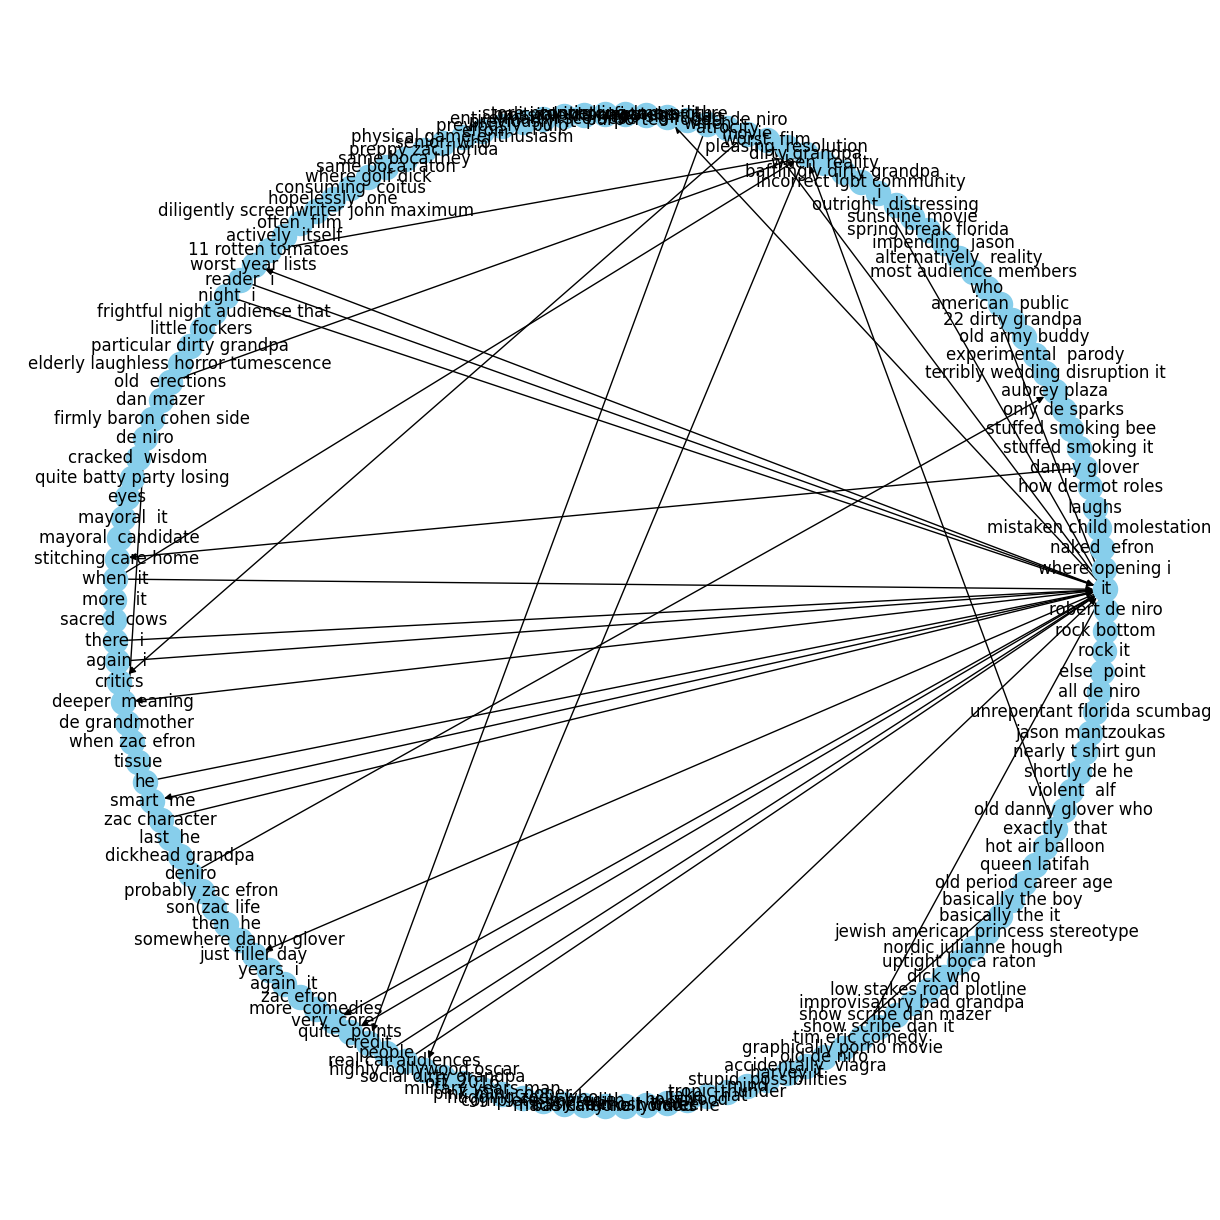

In [51]:
plot_graph(entities_kg_df, use_circular=True)

##BEGIN EXPERIMENTAL CODE


In [52]:
# I sometimes export the knowledge data-frames to Excel. I have found it useful to examine the results
# and hand edit the results and import them back for the semi-automated construction of the knowledge graph.

In [53]:
# kg_df.to_excel("kg.xlsx")

OpenAI extracts Entities

In [54]:
# If you want to try it, you'll need an account with OpenAI to use this experimental code.
# I spent under a dollar working on it as it's not expensive, but watch your spending, and set limit!
# Remember, the OpenAI API isn't free!
#
# Get API Key here:   https://platform.openai.com/account/api-keys
# Monitor usage:      https://platform.openai.com/account/usage
# Set usage limits:   https://platform.openai.com/account/billing/limits
#
# (Put your OpenAI key in the function parse_sentences_openai( ) .)
# I developed it in the starter code notebook and removed the extraneous cells so you can see what's new.

# There's basically two functions
#   (1) parse_sentences_openai( ) which makes the OpenAI API calls
#   (2) parse_openai_response( ) which takes the OpenAI API output and tries to put them
#         into a knowledge graph data-frame called global_kg_df2 .

In [55]:
#!pip install openai

In [56]:
# import nltk
# import pandas as pd
# import re
# #from nltk.tokenize import sent_tokenize
# import re
# from io import StringIO
# import openai
# import time

# nltk.download('punkt')

# def parse_openai_response(response):
#     print ("Response: ", response, "\n")
#     try:  # Parsing might blow up
#       # Check the style of the output and parse accordingly
#       if "Subject: " in response and "Verb: " in response and "Object: " in response:
#           if " - " in response:
#               chunks = response.strip().split("\n\n")
#               subjects, verbs, objects = [], [], []
#               for chunk in chunks:
#                   subject = re.search('Subject: (.*)', chunk)
#                   verb = re.search('Verb: (.*)', chunk)
#                   obj = re.search('Object: (.*)', chunk)
#                   if subject: subjects.append(subject.group(1).strip())
#                   if verb: verbs.append(verb.group(1).strip())
#                   if obj: objects.append(obj.group(1).strip())
#           else:
#               lines = response.strip().split("\n")
#               subjects, verbs, objects = [], [], []
#               for line in lines:
#                   subject = re.search('Subject: (.*?);', line)
#                   verb = re.search('Verb: (.*?);', line)
#                   obj = re.search('Object: (.*)', line)
#                   if subject: subjects.append(subject.group(1))
#                   if verb: verbs.append(verb.group(1))
#                   if obj: objects.append(obj.group(1))
#       elif "(" in response and ")" in response:
#           lines = response.strip().split("\n")
#           subjects, verbs, objects = [], [], []
#           for line in lines:
#               match = re.search('\((.*); (.*); (.*)\)', line)
#               if match:
#                   subjects.append(match.group(1).strip())
#                   verbs.append(match.group(2).strip())
#                   objects.append(match.group(3).strip())
#       elif ";" in response:
#           # Remove the leading numbers and period from each line
#           response = re.sub(r'\d+\.', '', response)

#           # Use StringIO to convert the string to a file-like object for use with pandas
#           data = StringIO(response)

#           # Read the data into a pandas DataFrame, specifying the separator and column names
#           df = pd.read_csv(data, sep=';', names=['source', 'edge', 'target'])

#           # Strip leading/trailing whitespace from each cell in the DataFrame
#           df = df.applymap(lambda x: x.strip() if isinstance(x, str) else x)
#           return df  # THERE ARE TWO RETURNS HERE. SHOULD CLEAN THIS UP IN THE FUTURE.

#       else:
#           subjects, verbs, objects = [], [], []
#           # raise ValueError("Unknown response format.")
#     except:
#       print ("Parsing ran into an error. Recovering.")
#       subjects, verbs, objects = [], [], []

#     try:
#       return_df= pd.DataFrame({'source': subjects, 'edge': verbs, 'target': objects})
#     except:
#       subjects, verbs, objects = [], [], []
#       return_df= pd.DataFrame({'source': subjects, 'edge': verbs, 'target': objects})

#     #return pd.DataFrame({'subject': subjects, 'verb': verbs, 'object': objects})
#     return return_df  # THERE ARE TWO RETURNS HERE. SHOULD CLEAN THIS UP IN THE FUTURE.


# def parse_sentences_openai(sentences, restart=0):
#     global global_kg_df2  # Use the global DataFrame

#     openai.api_key = 'PUT_IN_YOUR_OWN_OPENAI_KEY_HERE'
#     for i in range(restart, len(sentences)):
#         sentence = sentences[i]
#         print(f"Processing sentence {i}: {sentence}\n")
#         messages = [
#             {"role": "system", "content": "You are a helpful assistant that can extract separate tuples from English sentences of any complexity. The tuple should be in the form of (Subject; Verb; Object). Don't number the tuples. Dereference pronouns."},
#             {"role": "user", "content": sentence}
#         ]
#         response = openai.ChatCompletion.create(
#             model="gpt-3.5-turbo",
#             max_tokens=300,
#             temperature=0,
#             messages=messages
#         )
#         sentence_df = parse_openai_response(response['choices'][0]['message']['content'])
#         global_kg_df2 = global_kg_df2.append(sentence_df, ignore_index=True)
#         print ("From this sentence: ", len(sentence_df.index))
#         print ("Running total: ", len(global_kg_df2.index), "\n")
#         if (len(sentence_df.index)==0):
#             print ("NOTHING PARSED!")
#         time.sleep(10)   # I added a delay to avoid overwhelming the OpenAI servers. After I launched
#                          # this OpenAI code, I would do some chores and check back if it completed
#                          # or died. A 10 second delay may be excessive, so feel free to adjust
#                          # accordingly to your tastes and risk tolerance.
#     return global_kg_df2




In [57]:
# # Define a global DataFrame
# global_kg_df2 = pd.DataFrame(columns=['source', 'edge', 'target'])


In [58]:
# # If you want to experiment only at 5 sentences at first, you can specify a slice of the corpus_text_sentences array
# # like:
# #
# # parse_sentences_openai(corpus_text_sentences[:5],  0) # Work only on the first 5 sentences of the corpus

# # Once you feel comfortable with it and want to try to run it across the whole corpus, run it without a slice like:
# #

# parse_sentences_openai(corpus_text_sentences,  0) # Restart at sentence #0 or other sentence number, if you need to restart after OpenAI failure


# # In other words, I have found that the OpenAI calls sometimes fail or hang due to load and I need to restart the
# # parsing process again. I just look at the output to see what sentence it broke at.
# # Suppose it broke at sentence 30, then I can rerun parse_sentences_openai( ) with:
# #
# # parse_sentences_openai (corpus_text_sentences,  30)
# #
# # and it'll continue adding to the knowledge graph data-frame global_kg_df2 where it left off.

In [59]:
# global_kg_df2.shape

In [60]:
# For manual review or editing of the dataframes
#global_kg_df2.to_excel("kg2.xlsx")

In [61]:
# print(global_kg_df2)

In [62]:
# # Move everything to lower case
# global_kg_df2.source = global_kg_df2.source.str.lower()
# global_kg_df2.target = global_kg_df2.target.str.lower()
# global_kg_df2.edge = global_kg_df2.edge.str.lower()

# # Filter out empties
# global_kg_df2 = global_kg_df2[global_kg_df2.source != '']
# global_kg_df2 = global_kg_df2[global_kg_df2.target != '']
# global_kg_df2 = global_kg_df2[global_kg_df2.edge != ''].copy()

# # Filter out empties
# global_kg_df2 = global_kg_df2[global_kg_df2.source != 'NaN']
# global_kg_df2 = global_kg_df2[global_kg_df2.target != 'NaN']
# global_kg_df2 = global_kg_df2[global_kg_df2.edge != 'NaN'].copy()

In [63]:
# print(global_kg_df2)

In [64]:
# global_kg_df2.shape

In [65]:
# plot_graph(global_kg_df2, use_circular=True)

END EXPERIMENTAL CODE

## Recurrent Neural Network (RNN) Model Development

<img src="https://github.com/djp840/MSDS_453_Public/blob/main/images/BidirectionalRNN.png?raw=true">

<div class="alert alert-block alert-info">
    <b>tf.keras.layers.Bidirectional</b><br>
    https://www.tensorflow.org/api_docs/python/tf/keras/layers/Bidirectional
    </div>

In [66]:
datafull=corpus_df.copy()
datafull.reset_index(drop=True, inplace=True)
datafull.head(4).T

,0,1,2,3
DSI_Title,KCM_Doc1_AngelHasFallen,KCM_Doc2_AngelHasFallen,KCM_Doc3_AngelHasFallen,KCM_Doc4_AngelHasFallen
Text,Boredom sets in long before the start of Angel...,\nWho ARE all these people?\n\nThat was what...,Ric Roman Waughs Angel Has Fallen sees U.S. S...,There is a certain mindless pleasure in the Fa...
Submission File Name,KCM_Doc1_AngelHasFallen,KCM_Doc2_AngelHasFallen,KCM_Doc3_AngelHasFallen,KCM_Doc4_AngelHasFallen
Student Name,KCM,KCM,KCM,KCM
Genre of Movie,Action,Action,Action,Action
Review Type (pos or neg),Negative,Negative,Negative,Negative
Movie Title,Angel Has Fallen,Angel Has Fallen,Angel Has Fallen,Angel Has Fallen
Descriptor,Action_Angel Has Fallen_N_40,Action_Angel Has Fallen_N_41,Action_Angel Has Fallen_N_42,Action_Angel Has Fallen_N_43
Doc_ID,40,41,42,43
raw_sentences,[Boredom sets in long before the start of Ange...,[\nWho ARE all these people?\n\nThat was wha...,[Ric Roman Waughs Angel Has Fallen sees U.S. ...,[There is a certain mindless pleasure in the F...


In [67]:
datafull['Text'] = datafull['Text'].apply(lambda x :clean_doc(x))

## Preprocess DataSet

In [68]:
data = datafull[['Text','Genre of Movie']].copy()

In [69]:
data['Genre of Movie'] = data['Genre of Movie'].astype("category")
data['Genre of Movie code'] = data['Genre of Movie'].cat.codes
data['Genre of Movie code'].tail().T

,Genre of Movie code
195,3
196,3
197,3
198,3
199,3


## Review Examples by Genre

In [70]:
features, targets = data['Text'], data['Genre of Movie code']
data[["Genre of Movie","Genre of Movie code"]].value_counts()

,,count
Genre of Movie,Genre of Movie code,
Action,0,50
Comedy,1,50
Horror,2,50
Sci-Fi,3,50


## Create Datasets for Model Development

### Cell 10 - def get_dataset_partitions_pd

In [71]:
trainds, valds, testds = get_dataset_partitions_pd(data[['Text','Genre of Movie code']])
trainds.shape, valds.shape, testds.shape

((160, 2), (20, 2), (20, 2))

## Convert DataFrame to TensorFlow DataSet

In [72]:
# train X & y
train_text_ds_raw = tf.data.Dataset.from_tensor_slices(
            tf.cast(trainds['Text'].values, tf.string)
)
train_cat_ds_raw = tf.data.Dataset.from_tensor_slices(
            tf.cast(trainds['Genre of Movie code'].values, tf.int64),
  )
# test X & y
test_text_ds_raw = tf.data.Dataset.from_tensor_slices(
            tf.cast(testds['Text'].values, tf.string)
)
test_cat_ds_raw = tf.data.Dataset.from_tensor_slices(
            tf.cast(testds['Genre of Movie code'].values, tf.int64),
)
#val X & Y
val_text_ds_raw = tf.data.Dataset.from_tensor_slices(
            tf.cast(valds['Text'].values, tf.string)
)
val_cat_ds_raw = tf.data.Dataset.from_tensor_slices(
            tf.cast(valds['Genre of Movie code'].values, tf.int64),
)

## Create DataSets (X=Preprocessed Text, Y=Encoded Categories)

In [73]:
train_ds = tf.data.Dataset.zip(
    (
            train_text_ds_raw,
            train_cat_ds_raw
     )
)
test_ds = tf.data.Dataset.zip(
    (
            test_text_ds_raw,
            test_cat_ds_raw
     )
)
val_ds = tf.data.Dataset.zip(
    (
            val_text_ds_raw,
            val_cat_ds_raw
     )
)

## Create Data Pipelines (Batching, Shuffling, and Optimizing)

In [74]:
batch_size = 3
AUTOTUNE = tf.data.experimental.AUTOTUNE
buffer_size=train_ds.cardinality().numpy()

train_ds = train_ds.shuffle(buffer_size=buffer_size)\
                   .batch(batch_size=batch_size,drop_remainder=False)\
                   .cache()\
                   .prefetch(AUTOTUNE)

test_ds = test_ds.shuffle(buffer_size=buffer_size)\
                   .batch(batch_size=batch_size,drop_remainder=False)\
                   .cache()\
                   .prefetch(AUTOTUNE)


val_ds = val_ds.shuffle(buffer_size=buffer_size)\
                   .batch(batch_size=batch_size,drop_remainder=False)\
                   .cache()\
                   .prefetch(AUTOTUNE)

In [75]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 3 columns):
 #   Column               Non-Null Count  Dtype   
---  ------               --------------  -----   
 0   Text                 200 non-null    object  
 1   Genre of Movie       200 non-null    category
 2   Genre of Movie code  200 non-null    int8    
dtypes: category(1), int8(1), object(1)
memory usage: 2.3+ KB


## Create the Text Encoder

The raw text loaded by `tfds` needs to be processed before it can be used in a model. The simplest way to process text for training is using the `experimental.preprocessing.TextVectorization` layer. This layer has many capabilities, but this tutorial sticks to the default behavior.

Create the layer, and pass the dataset's text to the layer's `.adapt` method:
The processing of each sample contains the following steps:

    standardize each sample (usually lowercasing + punctuation stripping)
    split each sample into substrings (usually words)
    recombine substrings into tokens (usually ngrams)
    index tokens (associate a unique int value with each token)
    transform each sample using this index, either into a vector of ints or a dense float vector.

<div class="alert alert-block alert-info">
    <b>tf.keras.layers.TextVectorization</b><br>
   https://www.tensorflow.org/api_docs/python/tf/keras/layers/TextVectorization
    </div>

In [76]:
VOCAB_SIZE=5000
encoder = tf.keras.layers.TextVectorization(
    max_tokens=VOCAB_SIZE, standardize="lower_and_strip_punctuation", pad_to_max_tokens= True)
encoder.adapt(train_ds.map(lambda text, label: text), batch_size= None)

In [77]:
vocab = np.array(encoder.get_vocabulary())
len(vocab)

5000

In [78]:
vocab = np.array(encoder.get_vocabulary())
vocab[:20]

array(['', '[UNK]', 's', 'the', 'film', 'i', '’', 'movie', 'one', 'like',
       'time', 'it', 'get', 'make', 'nt', 'character', 'even', 'but',
       'scene', 'much'], dtype='<U16')

In [79]:
vocab[-20:]

array(['welltodo', 'wellplaced', 'weil', 'weighed', 'weariness',
       'weaponry', 'weakling', 'waynes', 'watsonâ\x80\x99s',
       'wasnâ\x80\x99t', 'washedout', 'warrior', 'warrant', 'warming',
       'ward', 'wander', 'wally', 'wallow', 'wallop', 'walked'],
      dtype='<U16')

## Example of Encoded Words

In [80]:
encoded_example = encoder('encanto we dont talk about bruno no no').numpy()
encoded_example[:]

array([   1,  185,    1,  849, 3054,    1,  121,  121])

In [81]:
len(encoder.get_vocabulary())

5000

In [82]:
encoder(data['Text'][0])

<tf.Tensor: shape=(507,), dtype=int64, numpy=
array([   1,   56,   84,  111,  444,  233,  336,    5,  111, 2101,    7,
       2993,   43, 2542,   59, 2182,  220,   59,  673,    9, 2152, 2682,
       2999,    1,  221,    1,    1, 3266,    1,    5,  683,    1, 3127,
        362, 1629,    1,  653,    5,   72,   59,  762, 3860,    9,   57,
         23,    7,    1,    1, 4492,  117,   72, 1351,  117,  204,  117,
          1,   11,  515,    8,  472, 1067, 3349,  109,    1,  100, 4098,
       1708,   97,   40, 1212,  245,  444,  233,  336,  638,  458,   35,
         40, 1212,   30,  309,    7,   83, 1217,  629,   40, 1365,  243,
         85, 2518,   30, 1274,  482,  417,    1,  292,  201,   35,  278,
       1708, 1317,  155,  515,  596, 2542, 2572,  109,   58,  187,  596,
        831,  744,   92, 3058, 3319,  359,  993,   64,  483,  909, 1378,
       3397,    1,  284,  507,  278,  204,    5, 3169, 1378,    1, 4706,
         29,   42, 2453,    1, 1146, 2683,  318, 1186, 1019, 1941,    5,
     

In [83]:
for example, label in train_ds.take(1):
  print('texts: ', example.numpy()[:1])
  print()

texts:  [b"Surrealism appear ineffably bizarre , inquisitively titillating , depending purely viewer 's intellect . Though realm surrealism highly nebulous complex , even slight attempt improvisation sometimes go awry open Pandora 's Box , making task highly improbable nigh impossible . This facet reality may pose handicap gifted director , genius Christopher Nolan , dabbles concept surrealism , also ingeniously blend element Science Fiction latest wonder named Inception . Nolan created niche decade back unleashing monster movie called Memento . He substantiated status conjuring movie like Insomnia , The Prestige , Batman Begins , The Dark Knight . His unremitting desire innovation uncanny craving foray unexplored realm imagination deservedly earned auteur tag , gave carte blanche story-teller like Nolan desperately need . It 's highly apparent Nolan take every possible advantage liberty filming Inception . Inception dreamlike , dream superior thing conceived silver screen . With entwi

In [84]:
#

## Build RNN Sequential Model

<div class="alert alert-block alert-info">
    <b>tf.keras.layers</b><br>
    https://www.tensorflow.org/api_docs/python/tf/keras/layers
    </div>

In [85]:
k.clear_session()
num_classes = 4

model_rnn = tf.keras.Sequential([
    encoder,
    tf.keras.layers.Embedding(
        input_dim=len(encoder.get_vocabulary()),
        output_dim=64,
        mask_zero=True  # Use masking to handle variable sequence lengths
    ),
    tf.keras.layers.Bidirectional(tf.keras.layers.SimpleRNN(64)),  # Replaced LSTM with SimpleRNN
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(num_classes, activation='softmax')  # num_classes = 4
])

In [86]:
model_rnn.compile(optimizer= tf.keras.optimizers.Adam( )
                 ,loss=tf.keras.losses.SparseCategoricalCrossentropy()
                 ,metrics=['accuracy'])

In [87]:
%%time
history_rnn = model_rnn.fit(train_ds
             ,epochs=200
             ,validation_data=val_ds
             #,validation_steps=3
             ,callbacks=[tf.keras.callbacks.EarlyStopping(monitor='val_accuracy', patience=2)])


Epoch 1/200
54/54 ━━━━━━━━━━━━━━━━━━━━ 27s 410ms/step - accuracy: 0.2000 - loss: 1.4057 - val_accuracy: 0.2000 - val_loss: 1.4209
Epoch 2/200
54/54 ━━━━━━━━━━━━━━━━━━━━ 21s 384ms/step - accuracy: 0.3978 - loss: 1.3076 - val_accuracy: 0.2000 - val_loss: 1.4594
Epoch 3/200
54/54 ━━━━━━━━━━━━━━━━━━━━ 22s 408ms/step - accuracy: 0.5770 - loss: 1.1930 - val_accuracy: 0.3500 - val_loss: 1.4397
Epoch 4/200
54/54 ━━━━━━━━━━━━━━━━━━━━ 40s 391ms/step - accuracy: 0.5057 - loss: 1.2065 - val_accuracy: 0.3000 - val_loss: 1.4965
Epoch 5/200
54/54 ━━━━━━━━━━━━━━━━━━━━ 42s 421ms/step - accuracy: 0.5726 - loss: 1.1332 - val_accuracy: 0.1000 - val_loss: 1.5828
CPU times: user 3min 9s, sys: 1.47 s, total: 3min 11s
Wall time: 2min 50s


## Model Performance Test Accuracy - RNN

In [88]:
test_loss, test_acc = model_rnn.evaluate(test_ds)

print('Test Loss: {}'.format(test_loss))
print('Test Accuracy: {}'.format(test_acc))

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.1931 - loss: 1.4893
Test Loss: 1.5290449857711792
Test Accuracy: 0.20000000298023224


## Plotting Performance Metrics - RNN

In [89]:
history_rnn_dict = history_rnn.history
history_rnn_dict.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

In [90]:
history_rnn_df=pd.DataFrame(history_rnn_dict)
history_rnn_df.tail().round(3)

,accuracy,loss,val_accuracy,val_loss
0,0.219,1.405,0.20,1.421
1,0.425,1.276,0.20,1.459
2,0.469,1.269,0.35,1.440
3,0.556,1.126,0.30,1.497
4,0.619,1.082,0.10,1.583


In [91]:
losses_rnn = history_rnn.history['loss']
accs_rnn = history_rnn.history['accuracy']
val_losses_rnn = history_rnn.history['val_loss']
val_accs_rnn = history_rnn.history['val_accuracy']
epochs_rnn = len(losses_rnn)

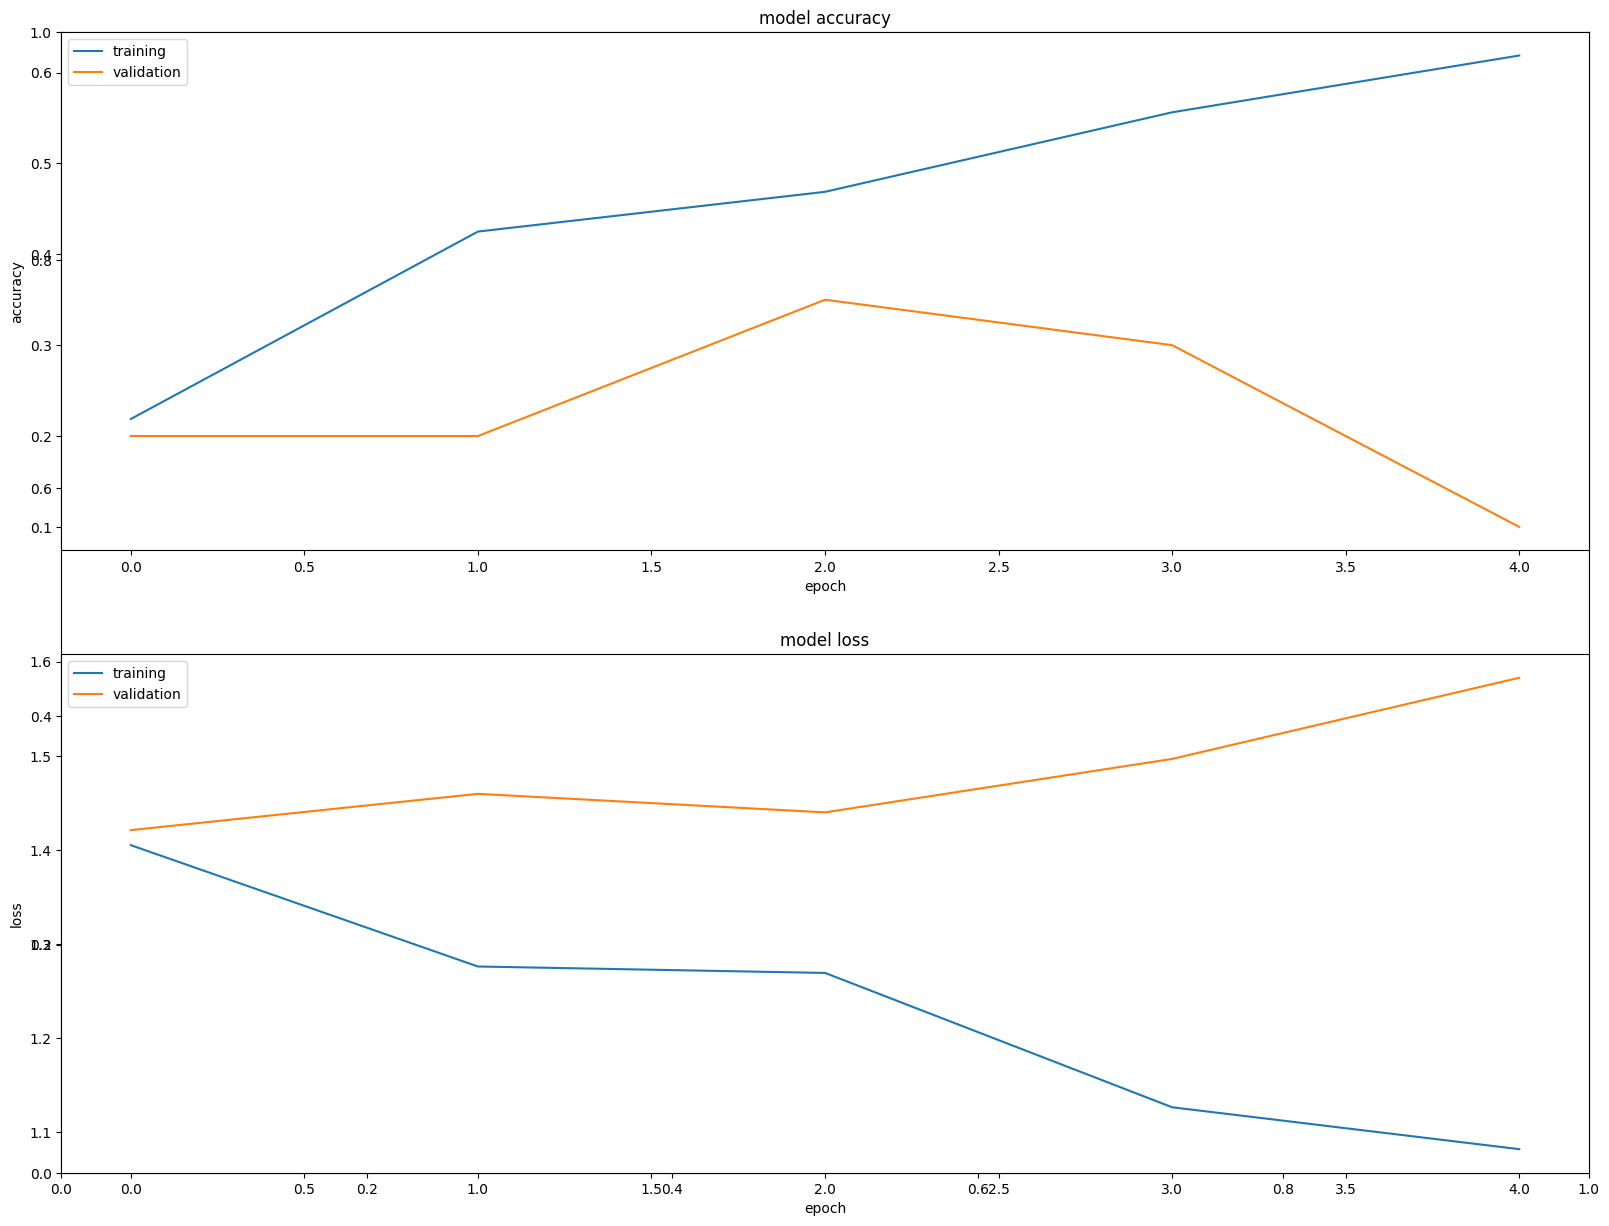

In [92]:
plt.subplots(figsize=(16,12))
plt.tight_layout()
display_training_curves(history_rnn.history['accuracy'], history_rnn.history['val_accuracy'], 'accuracy', 211)
display_training_curves(history_rnn.history['loss'], history_rnn.history['val_loss'], 'loss', 212)

## Confusion Matrix Post Model Performance Analysis - RNN

In [93]:
preds2_rnn = model_rnn.predict(test_ds)
y_pred2_rnn = np.argmax(preds2_rnn, axis=1)
y2_rnn = np.concatenate([y for x, y in test_ds], axis=0)

7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 96ms/step


In [94]:
CLASSES_LIST = ['Action','Comedy','Horror','Sci Fi']

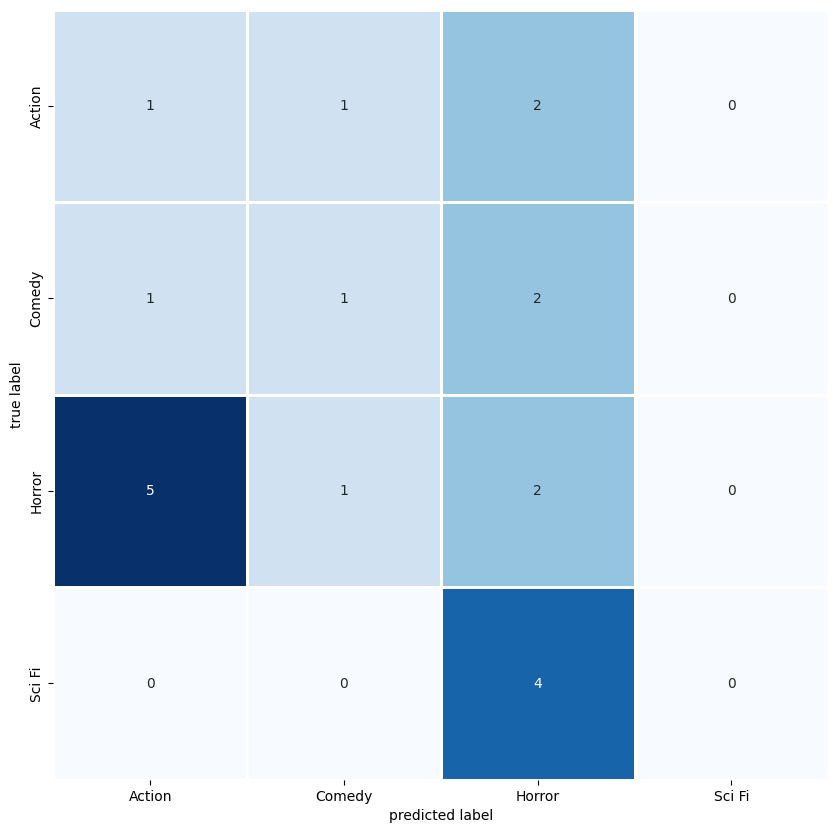

In [95]:
plot_confusion_matrix_labeled(y2_rnn,y_pred2_rnn, CLASSES_LIST=CLASSES_LIST)

In [96]:
cm = sns.light_palette((260, 75, 60), input="husl", as_cmap=True)

In [97]:
df2_rnn = pd.DataFrame(preds2_rnn[0:15]
                  ,columns = CLASSES_LIST).T
df2_rnn.style.format("{:.2%}").background_gradient(cmap=cm)

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14
Action,28.66%,19.59%,17.70%,41.34%,45.18%,30.91%,32.23%,38.79%,26.04%,36.92%,27.12%,35.83%,29.68%,25.26%,25.20%
Comedy,25.18%,23.21%,46.35%,14.80%,12.07%,23.81%,24.50%,19.11%,31.50%,23.15%,23.79%,17.02%,21.00%,31.15%,30.90%
Horror,20.18%,51.41%,18.42%,36.19%,23.75%,35.74%,21.05%,29.98%,35.18%,27.11%,35.47%,36.94%,30.52%,22.92%,33.25%
Sci Fi,25.98%,5.79%,17.53%,7.67%,19.00%,9.54%,22.22%,12.12%,7.27%,12.82%,13.62%,10.20%,18.79%,20.68%,10.65%


## RNN Model Architecture

In [98]:
model_rnn.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ text_vectorization              │ (None, None)           │             0 │
│ (TextVectorization)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding (Embedding)           │ (None, None, 64)       │       320,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,035,086 (3.95 MB)

 Trainable params: 345,028 (1.32 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 690,058 (2.63 MB)

In [99]:
#

## Build LSTM Sequential Model

<div class="alert alert-block alert-info">
    <b>tf.keras.layers</b><br>
    https://www.tensorflow.org/api_docs/python/tf/keras/layers
    </div>

In [100]:
k.clear_session()
num_classes=4
model_lstm=tf.keras.Sequential([encoder
   ,tf.keras.layers.Embedding(len(encoder.get_vocabulary()), 64, mask_zero=True)
   ,tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(64,  return_sequences=True, dropout=0.3))
   ,tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(32,dropout=0.3))
   ,tf.keras.layers.Dense(64, activation='relu')
   ,tf.keras.layers.Dense(num_classes,activation='softmax')
])

In [101]:
model_lstm.compile(optimizer= tf.keras.optimizers.Adam( )
                   ,loss=tf.keras.losses.SparseCategoricalCrossentropy()
                   ,metrics=['accuracy'])

In [102]:
%%time
history_lstm = model_lstm.fit(train_ds
         ,epochs=200
         ,validation_data=val_ds
         #,validation_steps=3
         ,callbacks=[tf.keras.callbacks.EarlyStopping(monitor='val_accuracy', patience=2)])

Epoch 1/200
54/54 ━━━━━━━━━━━━━━━━━━━━ 101s 2s/step - accuracy: 0.2689 - loss: 1.3853 - val_accuracy: 0.1500 - val_loss: 1.3900
Epoch 2/200
54/54 ━━━━━━━━━━━━━━━━━━━━ 73s 1s/step - accuracy: 0.3227 - loss: 1.3529 - val_accuracy: 0.4000 - val_loss: 1.2492
Epoch 3/200
54/54 ━━━━━━━━━━━━━━━━━━━━ 74s 1s/step - accuracy: 0.6078 - loss: 0.8931 - val_accuracy: 0.5000 - val_loss: 0.9747
Epoch 4/200
54/54 ━━━━━━━━━━━━━━━━━━━━ 71s 1s/step - accuracy: 0.8588 - loss: 0.3269 - val_accuracy: 0.7000 - val_loss: 0.8583
Epoch 5/200
54/54 ━━━━━━━━━━━━━━━━━━━━ 74s 1s/step - accuracy: 0.9672 - loss: 0.0942 - val_accuracy: 0.9000 - val_loss: 0.4419
Epoch 6/200
54/54 ━━━━━━━━━━━━━━━━━━━━ 80s 1s/step - accuracy: 1.0000 - loss: 0.0079 - val_accuracy: 0.9000 - val_loss: 0.4203
Epoch 7/200
54/54 ━━━━━━━━━━━━━━━━━━━━ 71s 1s/step - accuracy: 1.0000 - loss: 0.0040 - val_accuracy: 0.9500 - val_loss: 0.4026
Epoch 8/200
54/54 ━━━━━━━━━━━━━━━━━━━━ 73s 1s/step - accuracy: 1.0000 - loss: 0.0028 - val_accuracy: 0.9000 - 

## Model Performance Test Accuracy - LSTM

In [103]:
test_loss_lstm, test_acc_lstm = model_lstm.evaluate(test_ds)

print('Test Loss: {}'.format(test_loss_lstm))
print('Test Accuracy: {}'.format(test_acc_lstm))

7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 188ms/step - accuracy: 0.9806 - loss: 0.0779
Test Loss: 0.1311420351266861
Test Accuracy: 0.949999988079071


## Plotting Performance Metrics - Multi-Layer Bidirectional LSTM

In [104]:
history_lstm_dict = history_lstm.history
history_lstm_dict.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

In [105]:
history_lstm_df=pd.DataFrame(history_lstm_dict)
history_lstm_df.tail().round(3)

,accuracy,loss,val_accuracy,val_loss
4,0.981,0.056,0.90,0.442
5,1.000,0.007,0.90,0.420
6,1.000,0.004,0.95,0.403
7,1.000,0.003,0.90,0.396
8,1.000,0.002,0.90,0.391


In [106]:
losses_lstm = history_lstm.history['loss']
accs_lstm = history_lstm.history['accuracy']
val_losses_lstm = history_lstm.history['val_loss']
val_accs_lstm = history_lstm.history['val_accuracy']
epochs_lstm = len(losses_lstm)

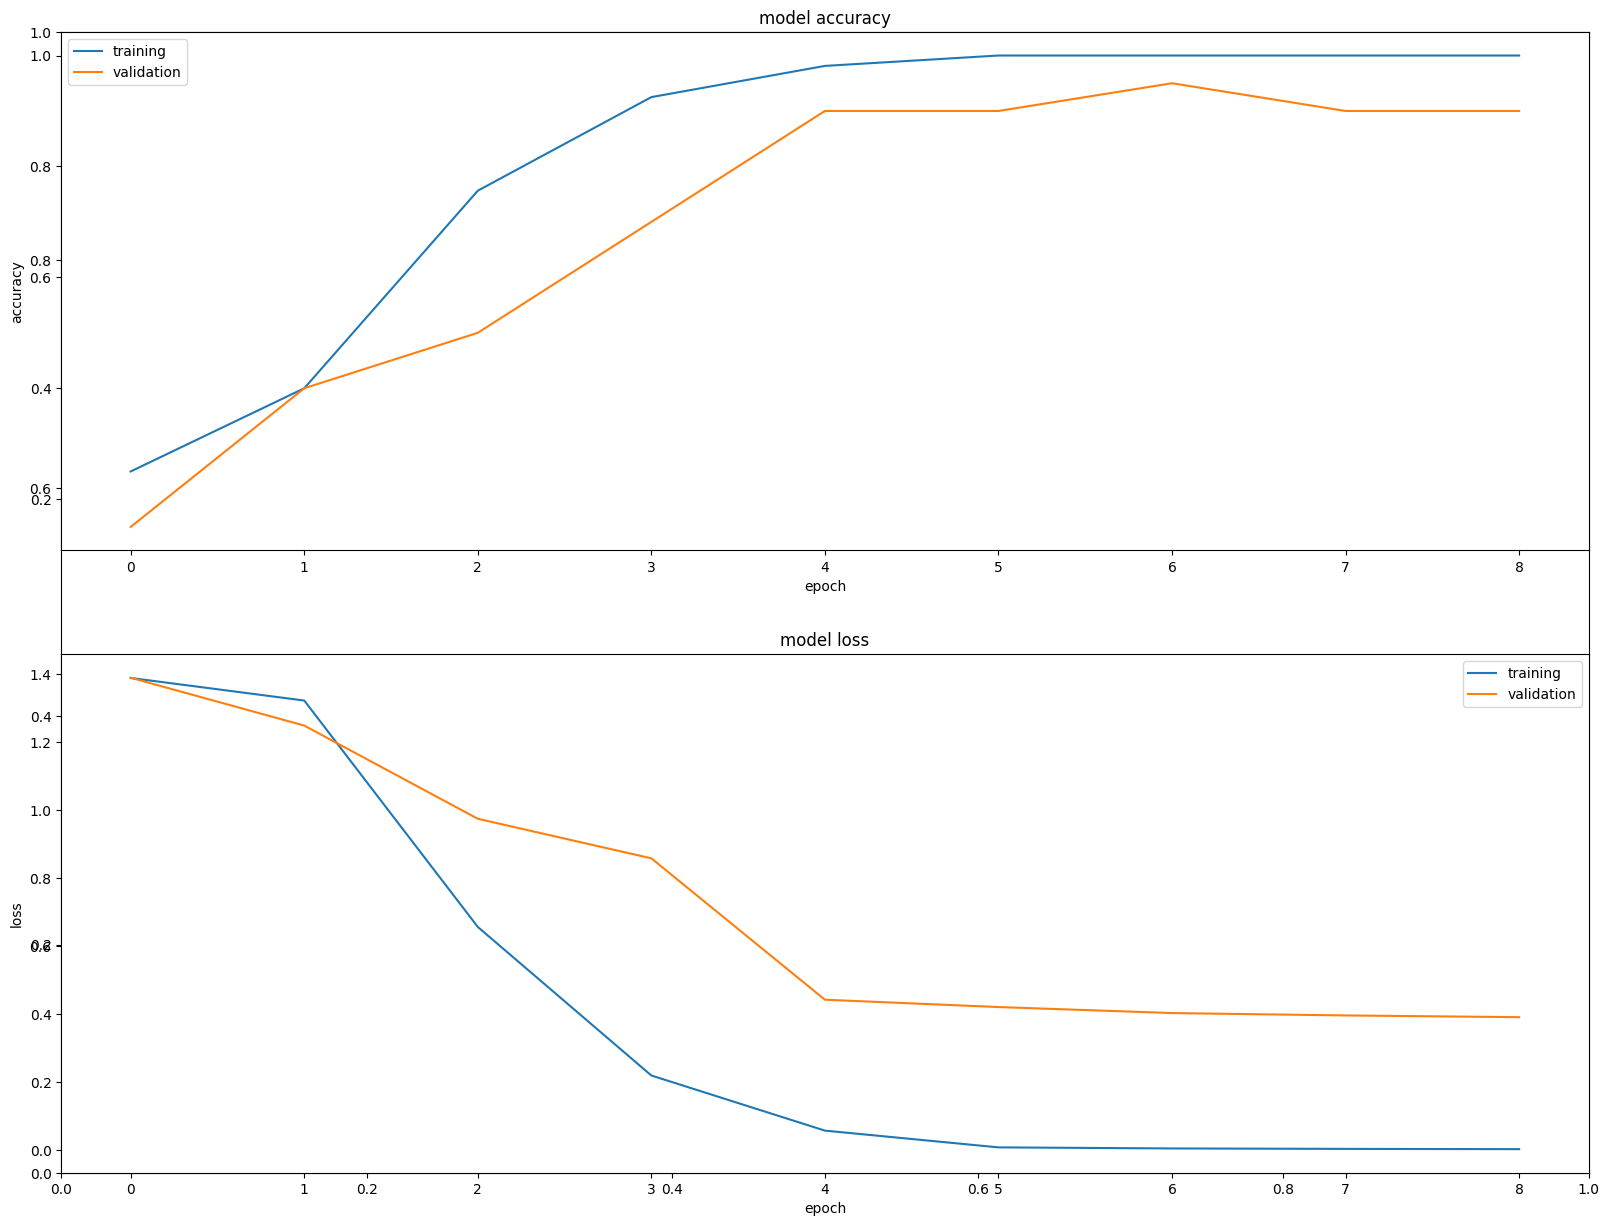

In [107]:
plt.subplots(figsize=(16,12))
plt.tight_layout()
display_training_curves(history_lstm.history['accuracy'], history_lstm.history['val_accuracy'], 'accuracy', 211)
display_training_curves(history_lstm.history['loss'], history_lstm.history['val_loss'], 'loss', 212)

## Confusion Matrix Post Model Performance Analysis - LSTM

In [108]:
preds2_lstm = model_lstm.predict(test_ds)
y_pred2_lstm = np.argmax(preds2_lstm, axis=1)
y2_lstm = np.concatenate([y for x, y in test_ds], axis=0)

7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 263ms/step


In [109]:
CLASSES_LIST = ['Action','Comedy','Horror','Sci Fi']

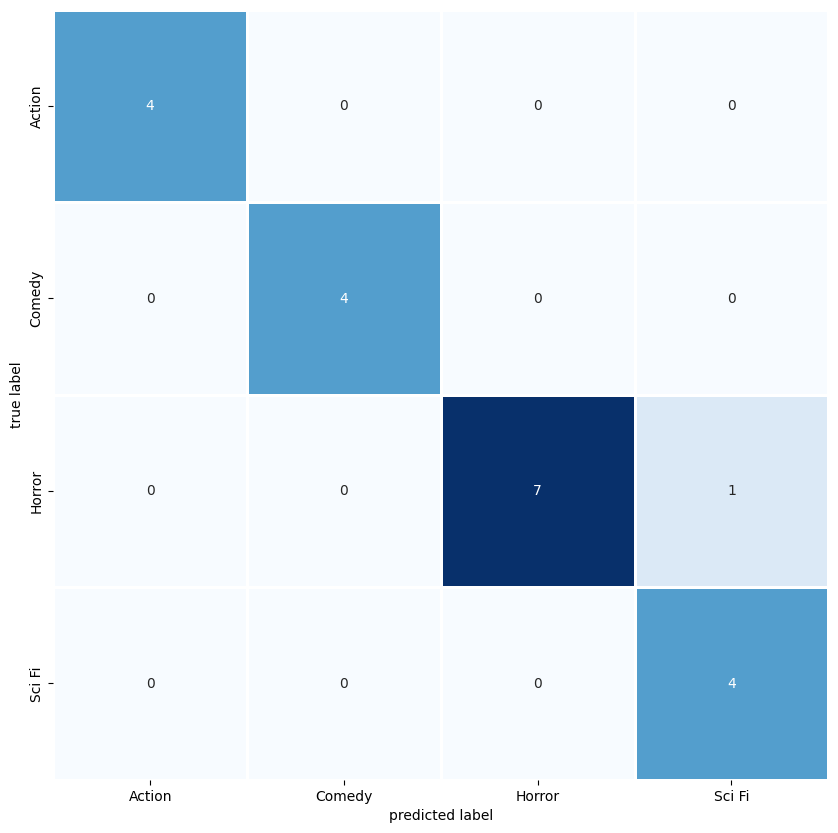

In [110]:
plot_confusion_matrix_labeled(y2_lstm,y_pred2_lstm, CLASSES_LIST=CLASSES_LIST)

In [111]:
cm = sns.light_palette((260, 75, 60), input="husl", as_cmap=True)

In [112]:
df2_lstm = pd.DataFrame(preds2_lstm[0:15]
                  ,columns = CLASSES_LIST).T
df2_lstm.style.format("{:.2%}").background_gradient(cmap=cm)

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14
Action,0.19%,89.50%,99.45%,91.11%,0.02%,0.97%,0.09%,0.04%,0.39%,0.11%,0.45%,89.63%,0.42%,0.04%,1.49%
Comedy,0.77%,7.67%,0.40%,5.26%,0.16%,2.00%,0.30%,0.23%,1.79%,0.80%,99.50%,10.06%,0.66%,99.87%,92.28%
Horror,98.34%,1.57%,0.02%,2.09%,99.66%,93.04%,98.78%,98.90%,1.37%,97.41%,0.01%,0.07%,0.09%,0.03%,0.28%
Sci Fi,0.70%,1.25%,0.14%,1.53%,0.16%,3.99%,0.83%,0.83%,96.45%,1.68%,0.04%,0.23%,98.83%,0.06%,5.96%


## LSTM Model Architecture

In [113]:
model_lstm.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ text_vectorization              │ (None, None)           │             0 │
│ (TextVectorization)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding (Embedding)           │ (None, None, 64)       │       320,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, None, 128)      │        66,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 64)             │        41,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,295,054 (4.94 MB)

 Trainable params: 431,684 (1.65 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 863,370 (3.29 MB)

In [114]:
#########################################
# Final Packaging Checklist for TA
#########################################

# Restore QA class corpus URL
# Delete OpenAI key
# Put sleep back to 10 seconds
# comment out openai experimental code
# fix Dirty_Grandpa vs Dirty Grandpa spelling difference

In [115]:
!pip list

Package                               Version
------------------------------------- -------------------
absl-py                               1.4.0
accelerate                            1.6.0
aiohappyeyeballs                      2.6.1
aiohttp                               3.11.15
aiosignal                             1.3.2
alabaster                             1.0.0
albucore                              0.0.24
albumentations                        2.0.6
ale-py                                0.11.0
altair                                5.5.0
annotated-types                       0.7.0
anyio                                 4.9.0
argon2-cffi                           23.1.0
argon2-cffi-bindings                  21.2.0
array_record                          0.7.2
arviz                                 0.21.0
astropy                               7.0.1
astropy-iers-data                     0.2025.4.28.0.37.27
astunparse                            1.6.3
atpublic                              5

In [116]:
!pip freeze

absl-py==1.4.0
accelerate==1.6.0
aiohappyeyeballs==2.6.1
aiohttp==3.11.15
aiosignal==1.3.2
alabaster==1.0.0
albucore==0.0.24
albumentations==2.0.6
ale-py==0.11.0
altair==5.5.0
annotated-types==0.7.0
anyio==4.9.0
argon2-cffi==23.1.0
argon2-cffi-bindings==21.2.0
array_record==0.7.2
arviz==0.21.0
astropy==7.0.1
astropy-iers-data==0.2025.4.28.0.37.27
astunparse==1.6.3
atpublic==5.1
attrs==25.3.0
audioread==3.0.1
autograd==1.7.0
babel==2.17.0
backcall==0.2.0
backports.tarfile==1.2.0
beautifulsoup4==4.13.4
betterproto==2.0.0b6
bigframes==2.1.0
bigquery-magics==0.9.0
bleach==6.2.0
blinker==1.9.0
blis==1.3.0
blosc2==3.3.2
bokeh==3.7.2
Bottleneck==1.4.2
bqplot==0.12.44
branca==0.8.1
build==1.2.2.post1
CacheControl==0.14.3
cachetools==5.5.2
catalogue==2.0.10
certifi==2025.4.26
cffi==1.17.1
chardet==5.2.0
charset-normalizer==3.4.1
chex==0.1.89
clarabel==0.10.0
click==8.1.8
cloudpathlib==0.21.0
cloudpickle==3.1.1
cmake==3.31.6
cmdstanpy==1.2.5
colorcet==3.1.0
colorlover==0.3.0
colour==0.1.5
commun